In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("exchange_rate.csv")
df

,date,Ex_rate
0,01-01-1990 00:00,0.785500
1,02-01-1990 00:00,0.781800
2,03-01-1990 00:00,0.786700
3,04-01-1990 00:00,0.786000
4,05-01-1990 00:00,0.784900
...,...,...
7583,06-10-2010 00:00,0.718494
7584,07-10-2010 00:00,0.721839
7585,08-10-2010 00:00,0.723197
7586,09-10-2010 00:00,0.720825


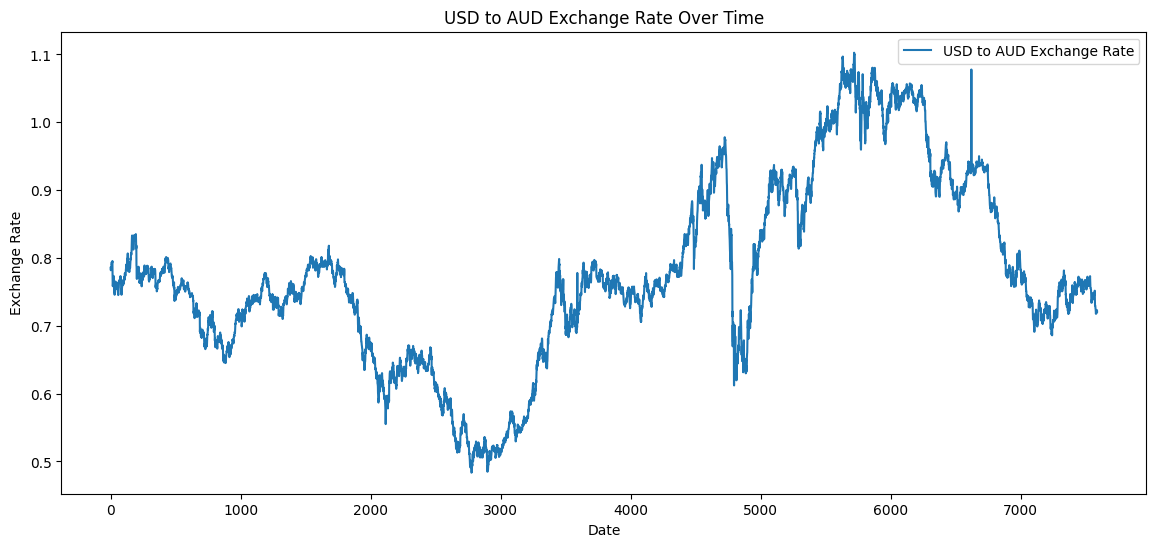

In [5]:
# Initial Exploration: Plot the USD to AUD exchange rate timeseries
plt.figure(figsize=(14,6))
plt.plot(df['Ex_rate'], label='USD to AUD Exchange Rate')
plt.title('USD to AUD Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()

In [6]:
#check for missing values
print("Missing values\n", df.isnull().sum())

Missing values
 date       0
Ex_rate    0
dtype: int64


In [7]:
# Handle missing values by forward fill
df['Ex_rate'] = df['Ex_rate'].fillna(method='ffill')

/tmp/ipython-input-385254390.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Ex_rate'] = df['Ex_rate'].fillna(method='ffill')


In [9]:
# Detect anomalies (using Z-score for simplicity)
z_scores = np.abs((df['Ex_rate'] - df['Ex_rate'].mean()) / df['Ex_rate'].std())
anomalies = df[z_scores  > 3]
print("Anomalies:\n", anomalies)


Anomalies:
 Empty DataFrame
Columns: [date, Ex_rate]
Index: []


In [10]:
#Remove anomalies by replacing with median or nearest values if needed
if not anomalies.empty:
  df.iloc[anomalies.index, 'Ex_rate'] = df['Ex_rate'].medain()

In [11]:
#Model Building - Arima

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

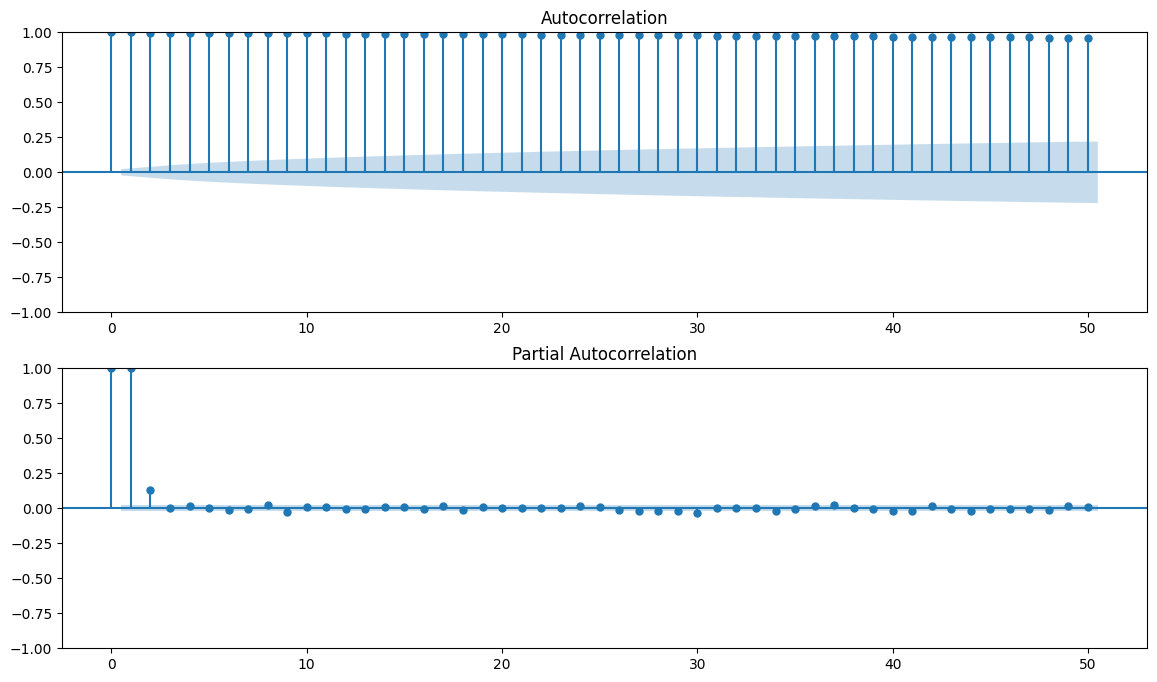

In [14]:
# Visualize ACF and PACF for parameter selection
fig, ax = plt.subplots(2,1, figsize=(14,8))
plot_acf(df['Ex_rate'], lags=50, ax=ax[0])
plot_pacf(df['Ex_rate'], lags=50, ax=ax[1])
plt.show()



In [15]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df['Ex_rate'])
print('ADF statistics:', result[0])
print('p_value:', result[1])
if result[1] > 0.05:
  d = 1
else:
  d = 0
p, q = 1, 1   #Start with (1, d, 1) as a simple initial guess


ADF statistics: -1.6649941807382342
p_value: 0.4492327353597477


In [17]:
# Fit ARIMA Model
model = ARIMA(df['Ex_rate'], order=(p,d,q))
arima_fit = model.fit()
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Thu, 18 Sep 2025   AIC                         -56102.322
Time:                        05:35:26   BIC                         -56081.519
Sample:                             0   HQIC                        -56095.182
                               - 7588                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.604      0.0

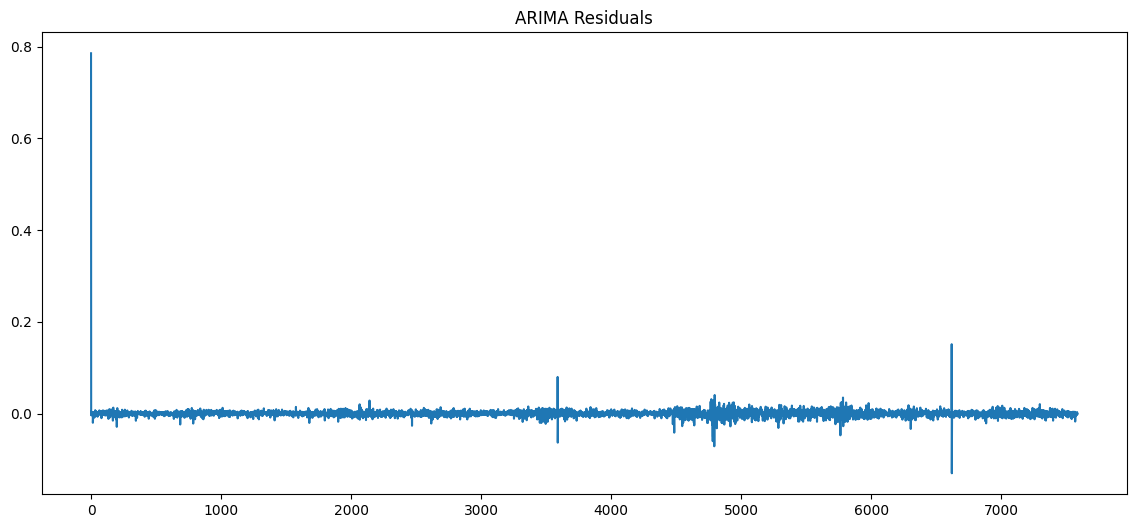

In [18]:
# Diagonastics
residuals = arima_fit.resid
plt.figure(figsize=(14,6))
plt.plot(residuals)
plt.title('ARIMA Residuals')
plt.show()

In [20]:
n_forecast = 30  # Forecasting 30 days ahead
arima_forecast = arima_fit.get_forecast(steps=n_forecast)
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

Text(0, 0.5, 'Exchange Rate')

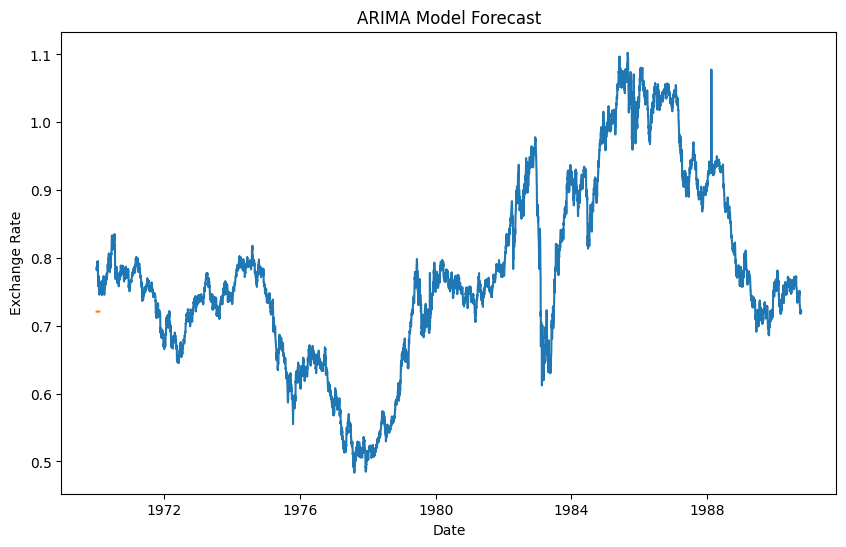

In [21]:
#forecasting
forecast = arima_fit.predict(start=len(df), end=len(df)+29)

plt.figure(figsize=(10, 6))
plt.plot(df.index, df['Ex_rate'], label='Actual')
plt.plot(pd.date_range(df.index[-1], periods=30, freq='D'), forecast, label='Forecast')
plt.title('ARIMA Model Forecast')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')

In [22]:
# MODEL BUILDING - EXPONENTIAL SMOOTHING

In [23]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Try Simple, Holt's, and Holt-Winters models
# Usually, exchange rates lack seasonality, try Holt first
es_model = ExponentialSmoothing(df['Ex_rate'], trend='add', seasonal=None)
es_fit = es_model.fit(optimized=True)
print(es_fit.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                  Ex_rate   No. Observations:                 7588
Model:             ExponentialSmoothing   SSE                              0.273
Optimized:                         True   AIC                         -77641.010
Trend:                         Additive   BIC                         -77613.272
Seasonal:                          None   AICC                        -77640.999
Seasonal Periods:                  None   Date:                 Thu, 18 Sep 2025
Box-Cox:                          False   Time:                         05:41:10
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.8698403                alpha                 True
smoothing_trend             0.0000

In [24]:
from sklearn.model_selection import ParameterGrid
param_grid = {
    'trend': [None, 'add', 'mul'],
    'seasonal': [None, 'add', 'mul'],
    'seasonal_periods': [None, 7, 12, 30]
}

best_aic = np.inf
best_params = None
best_model = None

for params in ParameterGrid(param_grid):
    try:
        model = ExponentialSmoothing(
            series,
            trend=params['trend'],
            seasonal=params['seasonal'],
            seasonal_periods=params['seasonal_periods']
        ).fit()
        aic = model.aic
        if aic < best_aic:
            best_aic = aic
            best_params = params
            best_model = model
    except Exception:
        continue

print('Best Params from Grid Search:', best_params)
print('Best AIC:', best_aic)

Best Params from Grid Search: None
Best AIC: inf


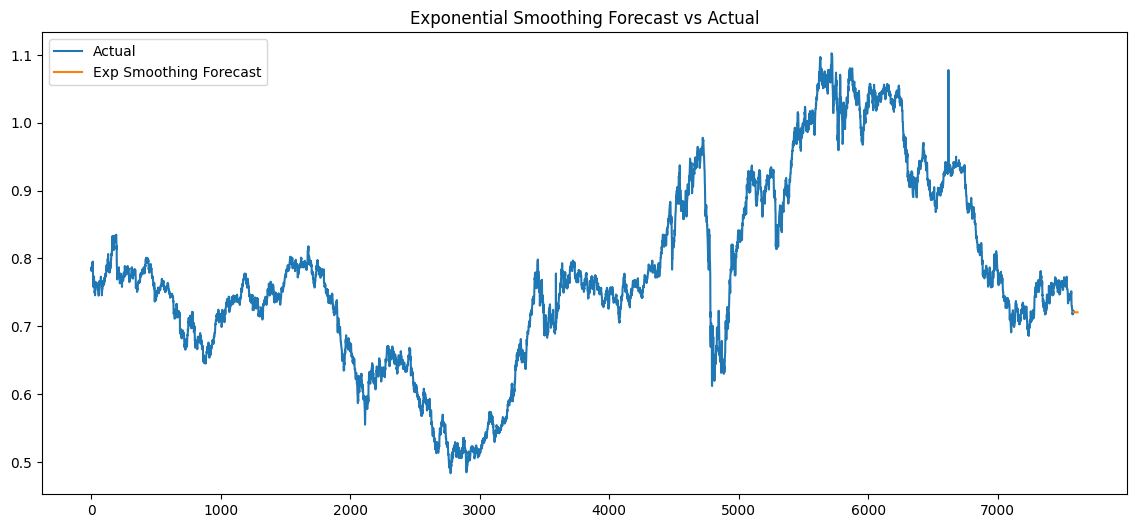

In [25]:
# Forecast future values
es_forecast = es_fit.forecast(n_forecast)

plt.figure(figsize=(14,6))
plt.plot(df['Ex_rate'], label='Actual')
plt.plot(es_forecast, label="Exp Smoothing Forecast")
plt.legend()
plt.title('Exponential Smoothing Forecast vs Actual')
plt.show()

In [26]:
#EVALUATION AND COMPARISON

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [28]:
# For error metrics, use the "last n_forecast" points
test_actual = df['Ex_rate'][-n_forecast:]

# To compare, use only available overlap in actuals
arima_pred = arima_fit.predict(start=test_actual.index[0], end=test_actual.index[-1])
es_pred = es_fit.predict(start=test_actual.index[0], end=test_actual.index[-1])

In [29]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

results = pd.DataFrame({
    'Model': ['ARIMA', 'Exp. Smoothing'],
    'MAE': [mean_absolute_error(test_actual, arima_pred), mean_absolute_error(test_actual, es_pred)],
    'RMSE': [np.sqrt(mean_squared_error(test_actual, arima_pred)), np.sqrt(mean_squared_error(test_actual, es_pred))],
    'MAPE': [mape(test_actual, arima_pred), mape(test_actual, es_pred)],
})
print(results)

            Model       MAE      RMSE      MAPE
0           ARIMA  0.002292  0.003864  0.312694
1  Exp. Smoothing  0.002300  0.003864  0.313654


In [30]:
print(results,"\n")

if results.loc[0, 'RMSE'] < results.loc[1, 'RMSE']:
    print("ARIMA model performed better on this dataset.")
else:
    print("Exponential Smoothing model performed better on this dataset.")
print("""
- ARIMA typically handles autocorrelations and trend well but may struggle with rapidly changing or nonlinear patterns.
- Exp Smoothing is robust to simple trend/seasonal patterns, easier to optimize, and faster to fit.
Model selection should depend on error metrics and residual diagnostics.
""")

            Model       MAE      RMSE      MAPE
0           ARIMA  0.002292  0.003864  0.312694
1  Exp. Smoothing  0.002300  0.003864  0.313654 

Exponential Smoothing model performed better on this dataset.

- ARIMA typically handles autocorrelations and trend well but may struggle with rapidly changing or nonlinear patterns.
- Exp Smoothing is robust to simple trend/seasonal patterns, easier to optimize, and faster to fit.
Model selection should depend on error metrics and residual diagnostics.

